In [1]:
import requests, pandas as pd, numpy as np
from pandas import DataFrame
from io import StringIO
import time, json
from datetime import date
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [2]:
df_fx_data=pd.read_csv('Datasets/BOE-XUDLERD.csv')
df_fx_data

,Date,Value
0,2017-11-09,0.8603
1,2017-11-08,0.8631
2,2017-11-07,0.8639
3,2017-11-06,0.8631
4,2017-11-03,0.8608
...,...,...
10832,1975-01-08,0.7554
10833,1975-01-07,0.7510
10834,1975-01-06,0.7524
10835,1975-01-03,0.7585


In [4]:
df_fx_data['Date']=pd.to_datetime(df_fx_data['Date'])
indexed_df=df_fx_data.set_index('Date')
print(indexed_df)
ts=indexed_df['Value']
ts.head(5)

             Value
Date              
2017-11-09  0.8603
2017-11-08  0.8631
2017-11-07  0.8639
2017-11-06  0.8631
2017-11-03  0.8608
...            ...
1975-01-08  0.7554
1975-01-07  0.7510
1975-01-06  0.7524
1975-01-03  0.7585
1975-01-02  0.7633

[10837 rows x 1 columns]


Date
2017-11-09    0.8603
2017-11-08    0.8631
2017-11-07    0.8639
2017-11-06    0.8631
2017-11-03    0.8608
Name: Value, dtype: float64

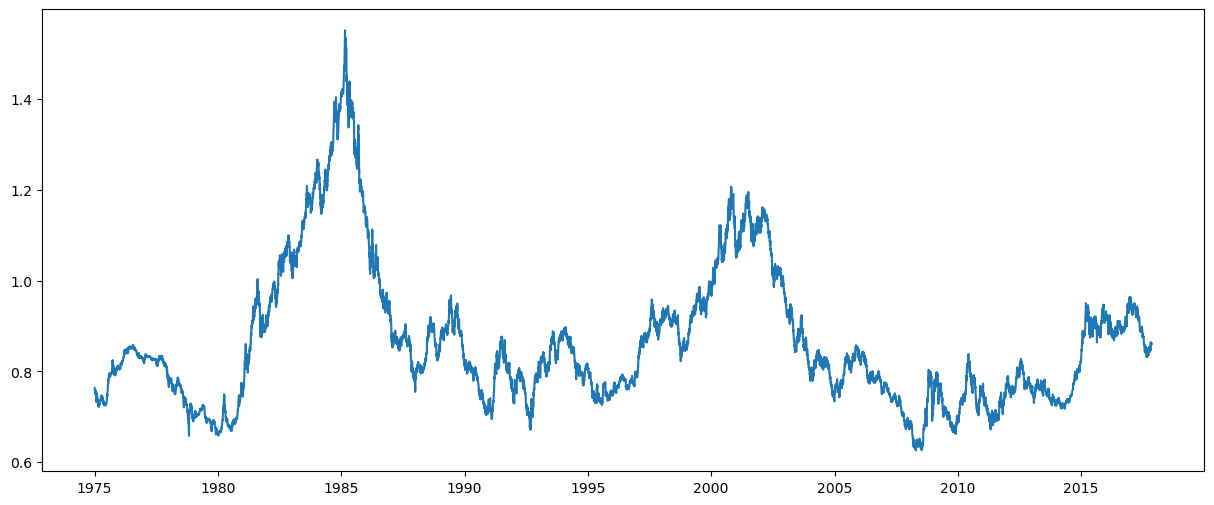

In [5]:
plt.plot(ts)

Date
1975-01-05    0.76090
1975-01-12    0.75346
1975-01-19    0.75546
1975-01-26    0.74388
1975-02-02    0.73902
               ...   
2017-10-15    0.84628
2017-10-22    0.84798
2017-10-29    0.85326
2017-11-05    0.85936
2017-11-12    0.86260
Freq: W-SUN, Name: Value, Length: 2237, dtype: float64


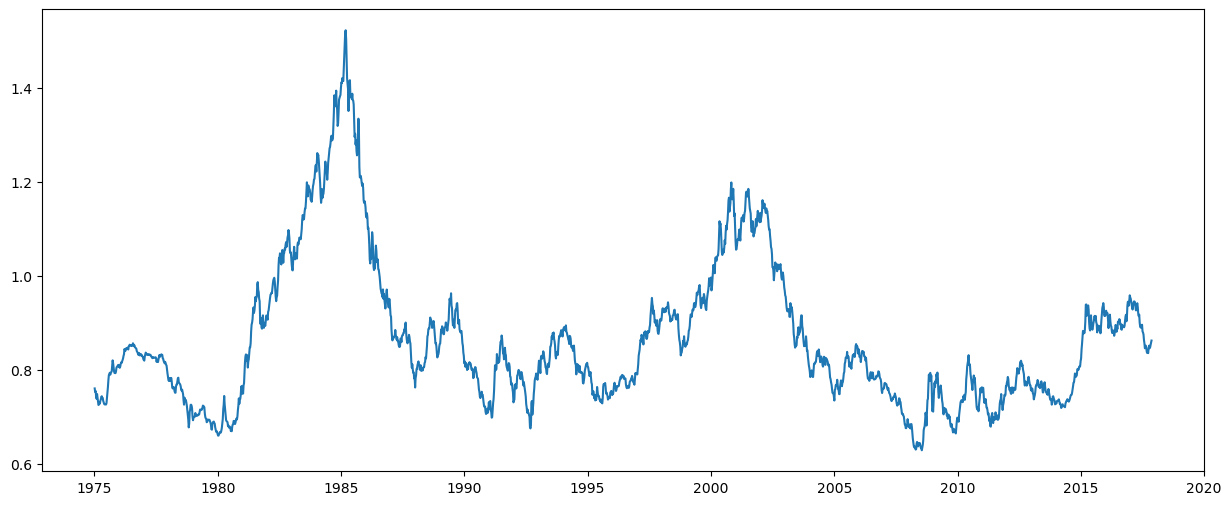

In [7]:
ts_week=ts.resample('W').mean()
print(ts_week)
plt.plot(ts_week)

Date
1975-01-05    0.76090
1975-01-12    0.75346
1975-01-19    0.75546
1975-01-26    0.74388
1975-02-02    0.73902
               ...   
2017-10-15    0.84628
2017-10-22    0.84798
2017-10-29    0.85326
2017-11-05    0.85936
2017-11-12    0.86260
Freq: W-SUN, Name: Value, Length: 2237, dtype: float64
Date
1975-01-05    0.76090
1975-01-12    0.75346
1975-01-19    0.75546
1975-01-26    0.74388
1975-02-02    0.73902
               ...   
2017-10-15    0.84628
2017-10-22    0.84798
2017-10-29    0.85326
2017-11-05    0.85936
2017-11-12    0.86260
Freq: W-SUN, Name: Value, Length: 2237, dtype: float64


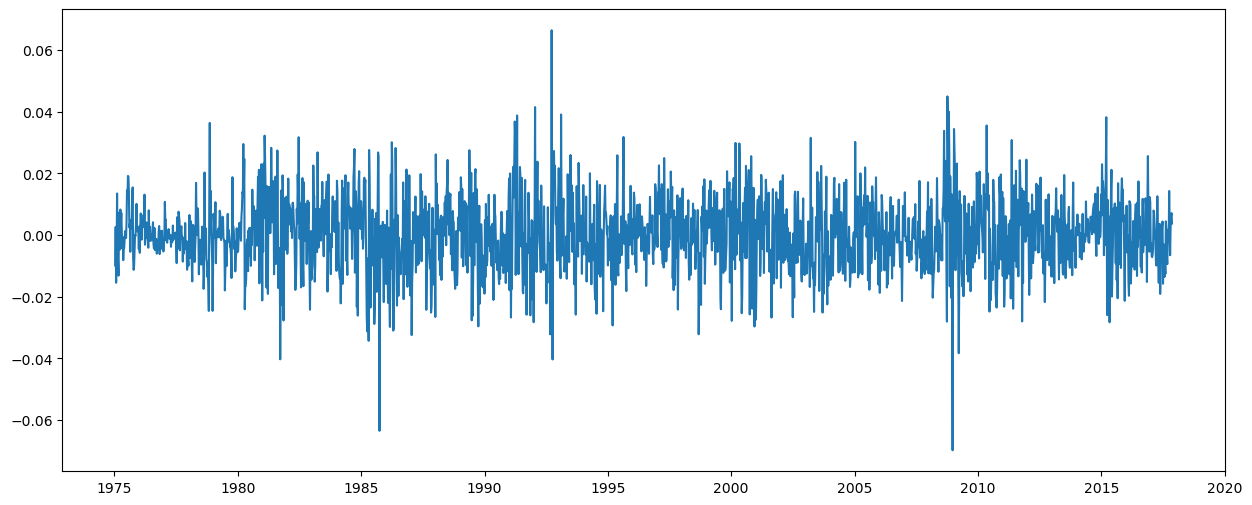

In [10]:
ts_week_log=np.log(ts_week)
print(ts_week)
ts_week_log_diff=ts_week_log-ts_week_log.shift()
print(ts_week)
plt.plot(ts_week_log_diff)

In [14]:
ts_week_log_diff.dropna(inplace=True)
print(ts_week_log_diff)

Date
1975-01-12   -0.009826
1975-01-19    0.002651
1975-01-26   -0.015447
1975-02-02   -0.006555
1975-02-09    0.013494
                ...   
2017-10-15   -0.006525
2017-10-22    0.002007
2017-10-29    0.006207
2017-11-05    0.007124
2017-11-12    0.003763
Freq: W-SUN, Name: Value, Length: 2236, dtype: float64


In [15]:
#CaseStudyTimeSeriesConcepts
import requests, pandas as pd, numpy as np
from pandas import DataFrame
from io import StringIO
import time, json
from datetime import date
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [16]:
df_fx_data=pd.read_csv('Datasets/SeaPlaneTravel.csv')
df_fx_data

,Month,#Passengers
0,2003-01,112
1,2003-02,118
2,2003-03,132
3,2003-04,129
4,2003-05,121
...,...,...
139,2015-08,606
140,2015-09,508
141,2015-10,461
142,2015-11,390


In [17]:
df_fx_data['Month']=pd.to_datetime(df_fx_data['Month'])
indexed_df=df_fx_data.set_index('Month')
ts=indexed_df['#Passengers']
ts.head()

Month
2003-01-01    112
2003-02-01    118
2003-03-01    132
2003-04-01    129
2003-05-01    121
Name: #Passengers, dtype: int64

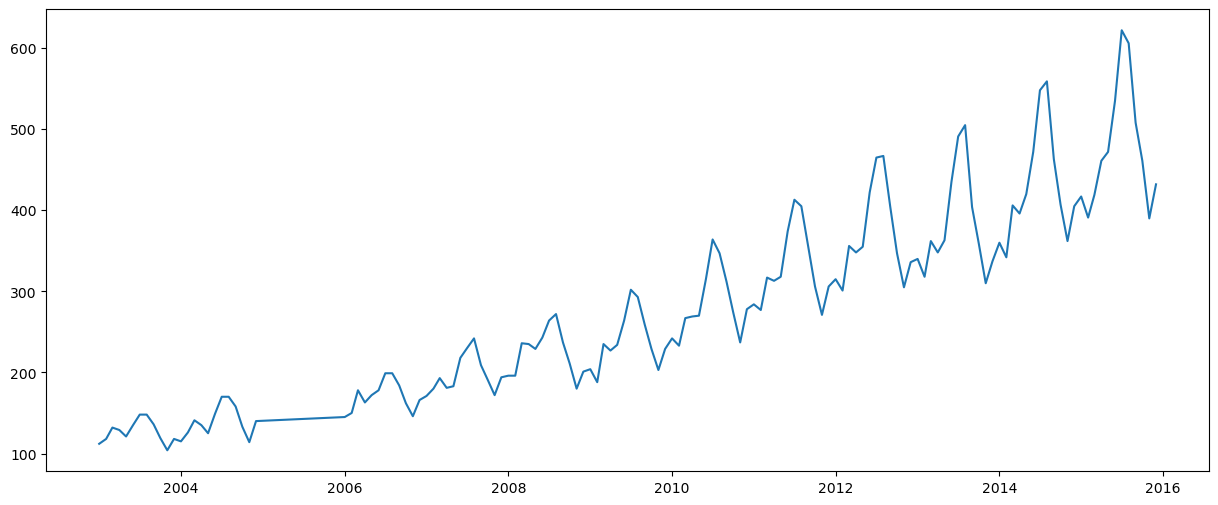

In [18]:
plt.plot(ts)

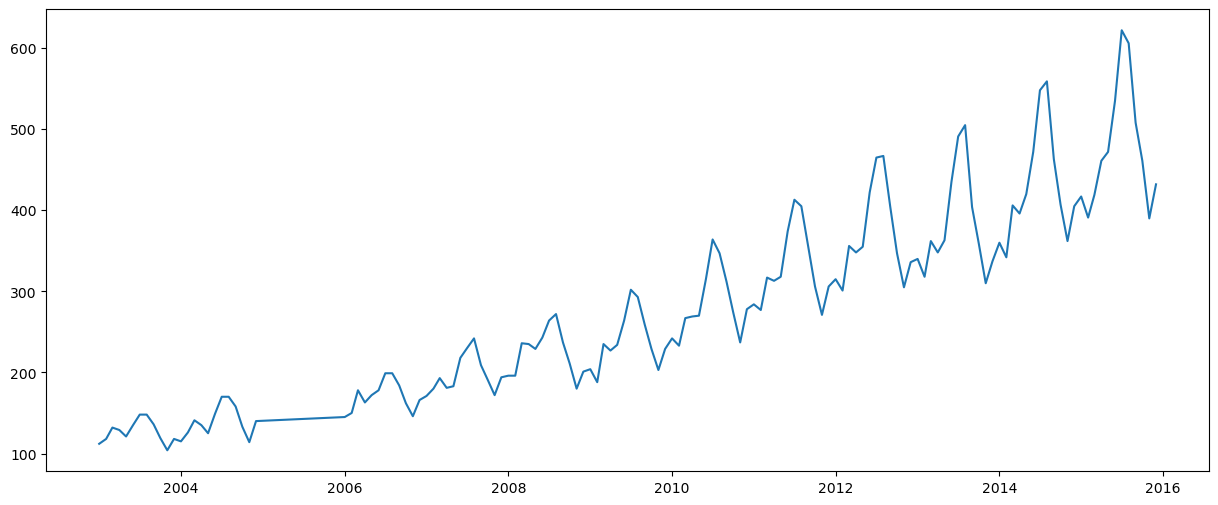

In [19]:
ts_month=ts
plt.plot(ts_month)